# Modelo com Rebalanceamento e Custos de Transação 

In [108]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [111]:
import pandas as pd

# Carrega os dados fundamentalistas dos anos 2021, 2022, 2023, 2024 e 2025
df_2021 = pd.read_excel('../../base_dados/base-dados-pesquisa/2021/ibovespa_magic_formula_2021.xlsx')
df_2022 = pd.read_excel('../../base_dados/base-dados-pesquisa/2022/ibovespa_magic_formula_2022.xlsx')
df_2023 = pd.read_excel('../../base_dados/base-dados-pesquisa/2023/ibovespa_magic_formula_2023.xlsx')
df_2024 = pd.read_excel('../../base_dados/base-dados-pesquisa/2024/ibovespa_magic_formula_2024.xlsx')
df_2025 = pd.read_excel('../../base_dados/base-dados-pesquisa/2025/ibovespa_magic_formula_2025.xlsx')

# Identifica empresas que estão em ２０２５ (filtro maior)
empresas_2025 = df_2025['ativo'].unique()

# Filtra 2021 pelas empresas de 2025
df_2021_filtrado = df_2021[df_2021['ativo'].isin(empresas_2025)]
# Filtra 2022 pelas empresas de 2025
df_2022_filtrado = df_2022[df_2022['ativo'].isin(empresas_2025)]
# Filtra 2023 pelas empresas de 2025
df_2023_filtrado = df_2023[df_2023['ativo'].isin(empresas_2025)]
# Filtra 2024 pelas empresas de 2025
df_2024_filtrado = df_2024[df_2024['ativo'].isin(empresas_2025)]

# Concatena um embaixo do outro
df_combinado = pd.concat([df_2021_filtrado, df_2022_filtrado, df_2023_filtrado, df_2024_filtrado, df_2025], ignore_index=True)

# Ordena por empresa e data (opcional, mas fica mais organizado)
df_combinado = df_combinado.sort_values(['ativo', 'dt_refer']).reset_index(drop=True)

# Salva
df_combinado.to_excel('../../base_dados/base-dados-pesquisa/juncao-anos/df_anos.xlsx', index=False)

print(f"✓ Total: {len(df_combinado)} linhas")
print(f"✓ Empresas: {df_combinado['ativo'].nunique()}")
print(f"✓ Datas: {sorted(df_combinado['dt_refer'].unique())}")

✓ Total: 947 linhas
✓ Empresas: 64
✓ Datas: ['2021-03-31', '2021-06-30', '2021-09-30', '2022-03-31', '2022-06-30', '2022-09-30', '2023-03-31', '2023-06-30', '2023-09-30', '2024-03-31', '2024-06-30', '2024-09-30', '2025-03-31', '2025-06-30', '2025-09-30']


In [112]:
basedados_ativos = Path('../../base_dados/retornos_ativos2.csv') 
basedados_ibov = Path('../../base_dados/retorno_ibov2.csv') 

path_df_mf = Path('../../base_dados/base-dados-pesquisa/juncao-anos/df_anos.xlsx') 

df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).dropna()

df_mf=pd.read_excel(path_df_mf).set_index(['ativo'])

In [113]:
df_mf

,ticker,dt_refer,preco,acoes_circ,valor_mercado,ebit,cap_investido,pl,EV,ROIC,earnings_yield,ROE,margem_liq,div_ebitda,ROA,giro_ativo,alavancagem
ativo,,,,,,,,,,,,,,,,,
ALLOS S.A.,ALOS3,2021-03-31,21.220156,264896090,5.621136e+09,59716,8145670,6589879,5.622692e+09,0.007331,0.000011,0.006355,1.150183,26.091500,0.005053,0.004393,0.187988
ALLOS S.A.,ALOS3,2021-06-30,22.581905,265129187,5.987122e+09,75256,8145634,6631102,5.988637e+09,0.009239,0.000013,0.008551,1.595751,20.133650,0.006876,0.004309,0.183717
ALLOS S.A.,ALOS3,2021-09-30,17.667385,265129187,4.684139e+09,75477,8454677,6693813,4.685900e+09,0.008927,0.000016,0.009051,1.413401,23.350358,0.007078,0.005008,0.205909
ALLOS S.A.,ALOS3,2022-03-31,17.993984,265149193,4.771090e+09,102890,6819290,6826904,4.771083e+09,0.015088,0.000022,0.008195,1.192468,0.000000,0.006128,0.005139,0.000000
ALLOS S.A.,ALOS3,2022-06-30,12.687920,265728995,3.371548e+09,75958,6700067,6708840,3.371539e+09,0.011337,0.000023,0.003512,0.536216,0.000000,0.002677,0.004993,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YDUQS PARTICIPACOES S.A.,YDUQ3,2024-06-30,9.549833,292360,2.791989e+06,150087,6703119,3142667,6.352441e+06,0.022391,0.023627,0.007744,inf,23.751611,0.003617,0.000000,0.529840
YDUQS PARTICIPACOES S.A.,YDUQ3,2024-09-30,8.504030,284871,2.422552e+06,243395,6796665,3217697,6.001520e+06,0.035811,0.040556,0.047212,inf,14.716120,0.022276,0.000000,0.525230
YDUQS PARTICIPACOES S.A.,YDUQ3,2025-03-31,10.586462,262093,2.774638e+06,295834,7901416,3118062,7.557992e+06,0.037441,0.039142,0.041268,0.086526,18.151345,0.013082,NaN,NaN


In [114]:
# df_mf = df_mf.filter(items=['ticker','dt_refer','earnings_yield','ROIC'])
df_mf['ticker'] = df_mf['ticker']+".SA"
df_mf['earnings_yield'].fillna(0, inplace=True)
df_mf_2021 = df_mf[df_mf['dt_refer'].str.contains('2021')]
df_mf_2022 = df_mf[df_mf['dt_refer'].str.contains('2022')]
df_mf_2023 = df_mf[df_mf['dt_refer'].str.contains('2023')]
df_mf_2024 = df_mf[df_mf['dt_refer'].str.contains('2024')]
df_mf_2025 = df_mf[df_mf['dt_refer'].str.contains('2025')]


C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\3952470534.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mf['earnings_yield'].fillna(0, inplace=True)


In [41]:
dados_retorno_2024 = df_ativos.query('Date >= "2024-01-01" and Date < "2024-12-31"')
dados_retorno_2025 = df_ativos.query('Date >= "2025-01-01" and Date < "2025-12-31"')
dados_retorno_2024 = dados_retorno_2024.filter(items=df_mf['ticker'].unique())
dados_retorno_2025 = dados_retorno_2025.filter(items=df_mf['ticker'].unique())
print(dados_retorno_2024.shape)
print(dados_retorno_2025.shape)


## IBOV

dados_retorno_ibov_2024 = df_ibov.query('Date >= "2024-01-01" and Date < "2024-12-31"')
dados_retorno_ibov_2024 = dados_retorno_ibov_2024.filter(items=['IBOV'])
dados_retorno_ibov_2024 = dados_retorno_ibov_2024.squeeze()
print(dados_retorno_ibov_2024.shape)

dados_retorno_ibov_2025 = df_ibov.query('Date >= "2025-01-01" and Date < "2025-12-31"')
dados_retorno_ibov_2025 = dados_retorno_ibov_2025.filter(items=['IBOV'])
dados_retorno_ibov_2025 = dados_retorno_ibov_2025.squeeze()
print(dados_retorno_ibov_2025.shape)



(250, 62)
(250, 62)
(250,)
(250,)


In [66]:
vb_cardinalidade_max = 30
vb_cardinalidade_min = 10
vb_peso_maximo = 0.15
vb_peso_minimo = 0.02
vb_theta = 3

# Modelo com dados fundamentalistas

In [67]:
score_2023_ativos = {}
i=0
for ticker in df_mf_2023['ticker'].unique():
    
    df_temp = df_mf_2023[df_mf_2023['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.5*df_temp['earnings_yield'] + 0.5*df_temp['ROIC']).sum()
    score_2023_ativos[i] = score_anual
    i=i+1
    

In [68]:
# ------ CRIAÇÃO DO MODELO
model = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model.nome_ativos = pyo.Set(initialize = dados_retorno_2024.columns)
model.ativos = pyo.RangeSet(0, len(dados_retorno_2024.columns)-1)
model.dias = pyo.RangeSet(0, len(dados_retorno_2024)-1)
model.retornos_ativos = pyo.Param(model.dias, model.ativos, initialize=lambda model,dia, ativo: dados_retorno_2024.iloc[dia, ativo])    
# model.retornos_ibov = pyo.Param(model.dias, initialize=lambda model,dia: dados_retorno_2024['IBOV'].iloc[dia])
model.theta = pyo.Param(initialize=vb_theta)

#Score do ano anterior utilizado pra frente
model.score = pyo.Param(model.ativos, initialize=lambda model, ativo: score_2023_ativos[ativo])

model.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)

# # Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
# model.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

# Definindo função objetivo
# a ideia na primeira parte é reduzir o erro quadrático
def func_objetivo_1(model):

    retorno_esperado = sum((sum(model.retornos_ativos[dia, a] * model.x[a] for a in model.ativos)) for dia in model.dias) 

    score_total = model.theta * sum(model.x[a] * model.score[a]  for a in model.ativos)

    # custo_cardinalidade = model.card_valor * 5
    
    return retorno_esperado + score_total 

model.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model.x[a] <= model.y[a]
model.const_restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model.x[a] <= model.peso_maximo

model.const_peso_maximo = pyo.Constraint(model.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model.x[a] >= model.peso_minimo * model.y[a]  # se y=1, então x >= 0.05
model.const_peso_minimo = pyo.Constraint(model.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model.x[a] for a in model.ativos) == 1
model.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model.y[a] for a in model.ativos
        ) <= model.cardinalidade_valor_max
model.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model.y[a] for a in model.ativos
        ) >= model.cardinalidade_valor_min
model.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmp17jbbxhc.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmpzrjs3eca.pyomo.lp' read.
Read time = 0.00 sec. (0.01 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmpzrjs3eca.pyomo.lp
Objective sense      : Maximize
Variables            :     124  [Box: 62,  Binary: 62]
Objective nonzeros   :      62
Linear constraints   :     189  [Less: 187,  Greater: 1,  Equal: 1]
  Nonzeros           :     496
  RHS nonzeros       :      65

Variables            : Min LB: 0.000000         Max UB: 1.00000

## MOSTRANDO RESULTADO DA 1 PRIMEIRA PARTE

In [69]:
lista_grande = []
for numero in range(len(dados_retorno_2024.columns)):
    peso_ativo = pyo.value(model.x[numero])
    ativado = pyo.value(model.y[numero])
    
    lista = [peso_ativo, ativado]
    lista_grande.append(lista)
print(lista_grande)
print(vb_cardinalidade_min)
print(vb_cardinalidade_max)
# print('cardinalidade escolhida: ',pyo.value(model.card_valor))

final = pd.DataFrame(lista_grande, columns=["peso_ativo","ativado"], index=dados_retorno_2024.columns)
print(len(final[final['ativado']!=0]))
print(final[final['ativado']!=0])

[[0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.02, 1.0], [0.0, 0.0], [0.02, 1.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.02, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.039999999999999813, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0]]
10
30
10
          peso_ativo  ativado
CMIG4.SA        0.15      1.0
SBSP3.SA        0.15      1.0
CPFE3.SA        

          peso_ativo  ativado
CMIG4.SA        0.15      1.0
SBSP3.SA        0.15      1.0
CPFE3.SA        0.02      1.0
DIRR3.SA        0.02      1.0
EMBJ3.SA        0.15      1.0
ITSA4.SA        0.02      1.0
MBRF3.SA        0.15      1.0
BEEF3.SA        0.04      1.0
PSSA3.SA        0.15      1.0
WEGE3.SA        0.15      1.0
157.58473142094272


C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\2422271459.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_otimizado[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\2422271459.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"


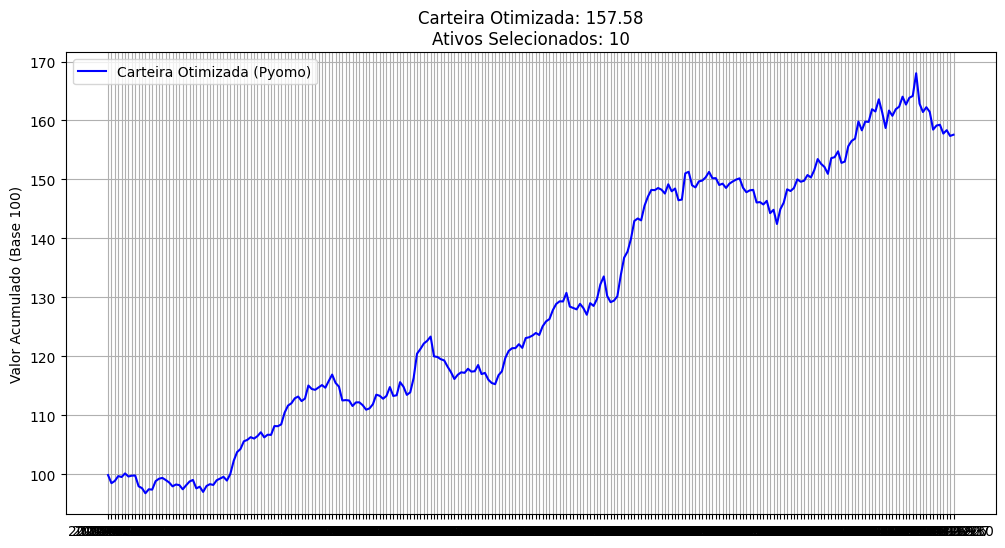

In [73]:
df_final = final[final['ativado']!=0]
print(df_final.head(20))
ativos_selecionados = df_final.index
retornos_carteira= dados_retorno_2024[ativos_selecionados]

carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100
# acum_equi = (carteira_equi).cumprod() * 100
# acum_ibov = (1 + retornos_ibov_primeira_metade['IBOV']).cumprod() * 100

print(acum_otimizado[-1])
# print(acum_equi[-1])
# print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
# plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### -------- 2º parte -  REBALANCEAMENTO

In [12]:
pesos_anteriores = {a: pyo.value(model.x[a]) for a in model.ativos}
pesos_anteriores

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.12000000000000002,
 10: 0.0,
 11: 0.12000000000000002,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.12000000000000002,
 19: 0.12000000000000002,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.03999999999999998,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.12000000000000002,
 36: 0.0,
 37: 0.12000000000000002,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.12000000000000002,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.0,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 60: 0.12000000000000002,
 61: 0.0}

In [13]:
score_2024_ativos = {}
i=0
for ticker in df_mf_2024['ticker'].unique():
    
    df_temp = df_mf_2024[df_mf_2024['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.5*df_temp['earnings_yield'] + 0.5*df_temp['ROIC']).sum()
    score_2024_ativos[i] = score_anual
    i=i+1

In [82]:
## a ideia aqui é Compra e Venda ,
## mas nao binária, ou seja, nao é 0 nao compra e 1 compra,
# é porcentagem, o quanto comprar e o quanto vender , envolvende uma custo de transação

#criando modelo novo
model_B = pyo.ConcreteModel()

model_B.ativos = pyo.RangeSet(0, len(dados_retorno_2025.columns)-1)
model_B.dias = pyo.RangeSet(0, len(dados_retorno_2025)-1)
model_B.ATIVOS_SEGUNDA_METADE = pyo.Param(model_B.dias, model_B.ativos,initialize=lambda model,dia, ativo: dados_retorno_2025.iloc[dia, ativo])
# model_B.IBOV_SEGUNDA_METADE = pyo.Param(model_B.dias, initialize = lambda model_B,dia: retornos_ibov_segunda_metade['IBOV'].iloc[dia])

#como se fosse o problema da lista de saber o Quanto a empresa deve produzir e o Quanto a empresa deve comprar o produto de outra

#Definindo variáveis de compra e venda, que serão as usadas
model_B.x = pyo.Var(model_B.ativos, bounds=(0,1)) #novos pesos 
model_B.y = pyo.Var(model_B.ativos, within=pyo.Binary) #nova cardinalidade 
model_B.compra =pyo.Var(model_B.ativos, bounds=(0,1))
model_B.venda =pyo.Var(model_B.ativos, bounds=(0,1))
custo_taxa = 0.0003 # = 0.03%


model_B.theta = pyo.Param(initialize=vb_theta)
model_B.score = pyo.Param(model_B.ativos, initialize=lambda model, ativo: score_2024_ativos[ativo])
model_B.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_B.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_B.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_B.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

#OBJETIVO
def func_objetivo_2(model_B):
    #como se trata de 2 momentos, o tracking e o custo de transação
    retorno_fundamentalista = sum((sum(model_B.ATIVOS_SEGUNDA_METADE[dia, ativo] * model_B.x[ativo] for ativo in model_B.ativos)) for dia in model_B.dias) + model_B.theta * sum(
        model_B.x[ativo]  * model_B.score[ativo] for ativo in model_B.ativos
    )
    
    score_total = model_B.theta * sum(model_B.x[a] * model_B.score[a]  for a in model_B.ativos)


    # Custo = taxa × (volume comprado + volume vendido)
    custo_transacao = sum(model_B.compra[ativo] + model_B.venda[ativo] for ativo in model_B.ativos) * custo_taxa

    return retorno_fundamentalista + score_total - custo_transacao
    # return retorno_fundamentalista

model_B.obj = pyo.Objective(rule=func_objetivo_2, sense=pyo.maximize)

#Restrições
#mais importante se a compra e venda será usada

def regra_equilibrio(model_B, ativo):
    return model_B.x[ativo] == pesos_anteriores[ativo] + model_B.compra[ativo] - model_B.venda[ativo]

model_B.regra_equilibrio = pyo.Constraint(model_B.ativos, rule=regra_equilibrio)

#restrições de soma peso 1 ; de x só ser ativado se y = 1 ; de cardinalidade 15 para y

def model_B_soma_peso_1(model_B):
    return sum(
        model_B.x[ativo] for ativo in model_B.ativos
    ) == 1
model_B.model_B_soma_peso_1 = pyo.Constraint( rule=model_B_soma_peso_1)

def model_B_y_cardinalidade_max(model_B):
    return sum(
        model_B.y[ativo] for ativo in model_B.ativos
    ) <= model_B.cardinalidade_valor_max
model_B.model_B_y_cardinalidade_total_max = pyo.Constraint(rule = model_B_y_cardinalidade_max)

def model_B_y_cardinalidade_min(model_B):
    return sum(
        model_B.y[ativo] for ativo in model_B.ativos
    ) >= model_B.cardinalidade_valor_min
model_B.model_B_y_cardinalidade_total_min = pyo.Constraint(rule = model_B_y_cardinalidade_min)

def model_B_x_y(model_B, ativo):
    return model_B.x[ativo] <= model_B.y[ativo]
model_B.model_B_x_y = pyo.Constraint(model_B.ativos, rule = model_B_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model_B.x[a] <= model_B.peso_maximo

model_B.const_peso_maximo = pyo.Constraint(model_B.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model_B.x[a] >= model_B.peso_minimo * model_B.y[a]  # se y=1, então x >= 0.05
model_B.const_peso_minimo = pyo.Constraint(model_B.ativos, rule=rule_peso_minimo)

def compra_ou_venda(model_B, ativo):
    """Um ativo ou é comprado OU vendido, nunca os dois"""
    return model_B.compra[ativo] + model_B.venda[ativo] <= 1

model_B.compra_ou_venda = pyo.Constraint(model_B.ativos, rule=compra_ou_venda)

# def model_B_y_desativa_se_x_zero(model_B, ativo):
#     """
#     Se x é pequeno (< peso_minimo), força y=0
#     Equivalente a: y <= x / peso_minimo
#     """
#     return model_B.y[ativo] <= model_B.x[ativo] / (model_B.peso_minimo + 0.00001)

# model_B.const_y_desativa = pyo.Constraint(model_B.ativos, rule=model_B_y_desativa_se_x_zero)



opt_B = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt_B.options['TimeLimit'] = 300
resultado = opt_B.solve(model_B)



resultado = opt_B.solve(model_B, tee=True)
print(f"\nStatus: {resultado.solver.status}")
print(f"Termination: {resultado.solver.termination_condition}")
print("-------FIM----------")


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpz2y2xj5q.cplex.log' open.
CPLEX> New value for time limit in seconds: 300
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp0o766uej.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp0o766uej.pyomo.lp
Objective sense      : Maximize
Variables            :     248  [Box: 186,  Binary: 62]
Objective nonzeros   :     186
Linear constraints   :     313  [Less: 249,  Greater: 1,  Equal: 63]
  Nonzeros           :     806
  RHS nonzeros       :     136

Variables            : Min LB: 0.000000 

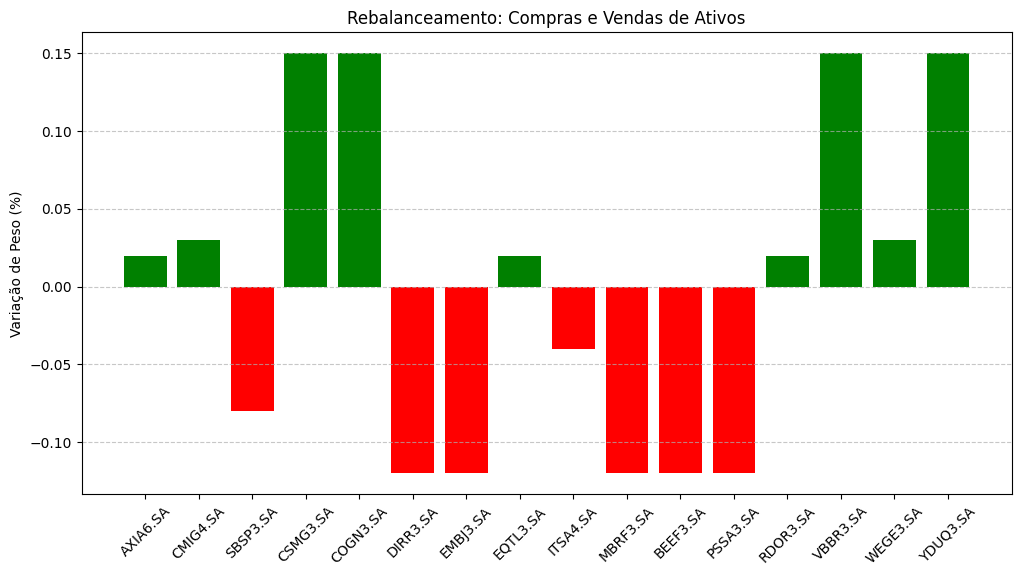

In [83]:
# Extrair os valores de compra e venda do model_B
mudancas_compra = []
mudancas_venda = []
mudancas = []
for a in range(len(dados_retorno_2024.columns)):
    c = pyo.value(model_B.compra[a])
    v = pyo.value(model_B.venda[a])
   
    mudancas.append(c if c > 0.00001 else -v)

    
    # Se comprou, valor positivo; se vendeu, valor negativo
    mudancas_compra.append(c)
    mudancas_venda.append(v)

x_peso_final = []
y_ativado_final = []

for a in range(len(dados_retorno_2024.columns)):
    lista_x = pyo.value(model_B.x[a])
    lista_y = pyo.value(model_B.y[a])

    x_peso_final.append(lista_x)
    y_ativado_final.append(lista_y)
    
lista_peso_anterior = df_final['peso_ativo'].tolist()
df_mudancas = pd.DataFrame({'Ativo': dados_retorno_2024.columns,'Mudança': mudancas, 'Mudança_Compra': mudancas_compra,"Mudança_venda":mudancas_venda,'Ativado':y_ativado_final, "Peso_otimizado":x_peso_final})
# carteira_final['peso_anterior'] = lista_peso_anterior

df_mudancas2 = df_mudancas[df_mudancas['Mudança'].abs() > 0.0001] # Filtrar apenas o que mudou
carteira_final = df_mudancas[df_mudancas['Ativado']>0.5]


plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in df_mudancas2['Mudança']]
plt.bar(df_mudancas2['Ativo'], df_mudancas2['Mudança'], color=colors)
plt.xticks(rotation=45)
plt.title('Rebalanceamento: Compras e Vendas de Ativos')
plt.ylabel('Variação de Peso (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [84]:
carteira_final

,Ativo,Mudança,Mudança_Compra,Mudança_venda,Ativado,Peso_otimizado
3,AXIA6.SA,0.02,0.02,0.00,1.0,0.02
9,CMIG4.SA,0.03,0.03,0.00,1.0,0.15
11,SBSP3.SA,-0.08,0.00,0.08,1.0,0.04
12,CSMG3.SA,0.15,0.15,0.00,1.0,0.15
14,COGN3.SA,0.15,0.15,0.00,1.0,0.15
23,EQTL3.SA,0.02,0.02,0.00,1.0,0.02
46,RDOR3.SA,0.02,0.02,0.00,1.0,0.02
58,VBBR3.SA,0.15,0.15,0.00,1.0,0.15
60,WEGE3.SA,0.03,0.03,0.00,1.0,0.15
61,YDUQ3.SA,0.15,0.15,0.00,1.0,0.15


In [103]:
print(len(df_final))
print(df_final)
print(df_mudancas2)
print(carteira_final)
print(len(carteira_final))

10
          peso_ativo  ativado
CMIG4.SA        0.15      1.0
SBSP3.SA        0.15      1.0
CPFE3.SA        0.02      1.0
DIRR3.SA        0.02      1.0
EMBJ3.SA        0.15      1.0
ITSA4.SA        0.02      1.0
MBRF3.SA        0.15      1.0
BEEF3.SA        0.04      1.0
PSSA3.SA        0.15      1.0
WEGE3.SA        0.15      1.0
       Ativo  Mudança  Mudança_Compra  Mudança_venda  Ativado  Peso_otimizado
3   AXIA6.SA     0.02            0.02           0.00      1.0            0.02
9   CMIG4.SA     0.03            0.03           0.00      1.0            0.15
11  SBSP3.SA    -0.08            0.00           0.08      1.0            0.04
12  CSMG3.SA     0.15            0.15           0.00      1.0            0.15
14  COGN3.SA     0.15            0.15           0.00      1.0            0.15
18  DIRR3.SA    -0.12            0.00           0.12      0.0            0.00
19  EMBJ3.SA    -0.12            0.00           0.12      0.0            0.00
23  EQTL3.SA     0.02            0.02      

In [18]:
carteira_final.shape

(9, 6)

C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\3952749297.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"


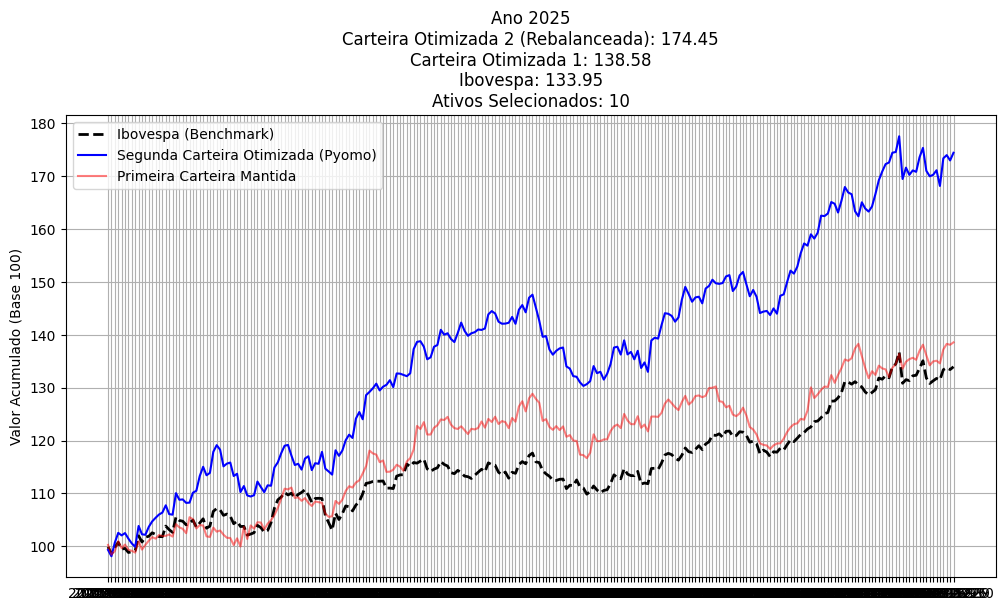

In [105]:
carteira_final2 = carteira_final['Peso_otimizado'].reset_index().drop(columns=['index']).set_index(carteira_final['Ativo'])
ativos_selecionados2 = carteira_final['Ativo'].tolist()
retornos_carteira2 = dados_retorno_2025[ativos_selecionados2]
carteira_otimizada2 = 1 + (retornos_carteira2*carteira_final2['Peso_otimizado']).sum(axis=1)

ativos_carteira_primeira = df_final.index
retornos_carteira_primeira = dados_retorno_2025[ativos_carteira_primeira]
carteira_primeira = 1 +(retornos_carteira_primeira*df_final['peso_ativo']).sum(axis=1)

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado2 = (carteira_otimizada2).cumprod() *100
acum_otimizado1 = (carteira_primeira).cumprod() *100
# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov2 = (1 + dados_retorno_ibov_2025).cumprod() * 100

# print(acum_otimizado2[-1])
# # print(acum_equi[-1])
# print(acum_ibov2[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov2, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado2, label='Segunda Carteira Otimizada (Pyomo)', color='blue')
plt.plot(acum_otimizado1, label='Primeira Carteira Mantida', color='red', alpha=0.5)

# texto_titulo = f'Comparação de Performance: Index Tracking ({tamanho_carteira_final} ativos)'
texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"

plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### ==========================================
### Usar Pietroski 
### ==========================================

In [87]:
score_2023_ativos_pietroski = {}
i=0
for ticker in df_mf_2023['ticker'].unique():
    
    df_temp = df_mf_2023[df_mf_2023['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.25*df_temp['ROA']+0.25*df_temp['margem_liq'] + 0.25*df_temp['giro_ativo'] + 0.25*df_temp['alavancagem']).sum()
    score_2023_ativos_pietroski[i] = score_anual
    i=i+1


# ------ CRIAÇÃO DO MODELO
model_pietroski_1 = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model_pietroski_1.nome_ativos = pyo.Set(initialize = dados_retorno_2024.columns)
model_pietroski_1.ativos = pyo.RangeSet(0, len(dados_retorno_2024.columns)-1)
model_pietroski_1.dias = pyo.RangeSet(0, len(dados_retorno_2024)-1)
model_pietroski_1.retornos_ativos = pyo.Param(model_pietroski_1.dias, model_pietroski_1.ativos, initialize=lambda model,dia, ativo: dados_retorno_2024.iloc[dia, ativo])    
# model_pietroski_1.retornos_ibov = pyo.Param(model_pietroski_1.dias, initialize=lambda model,dia: dados_retorno_2024['IBOV'].iloc[dia])
model_pietroski_1.theta = pyo.Param(initialize=vb_theta)

#Score do ano anterior utilizado pra frente
model_pietroski_1.score = pyo.Param(model_pietroski_1.ativos, initialize=lambda model, ativo: score_2023_ativos_pietroski[ativo])

model_pietroski_1.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_pietroski_1.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_pietroski_1.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_pietroski_1.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model_pietroski_1.x = pyo.Var(model_pietroski_1.ativos, bounds=(0,1))
model_pietroski_1.y = pyo.Var(model_pietroski_1.ativos, within=pyo.Binary)

# # Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
# model_pietroski_1.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

# Definindo função objetivo
# a ideia na primeira parte é reduzir o erro quadrático
def func_objetivo_1(model):

    retorno_esperado = sum((sum(model_pietroski_1.retornos_ativos[dia, a] * model_pietroski_1.x[a] for a in model_pietroski_1.ativos)) for dia in model_pietroski_1.dias) 

    score_total = model_pietroski_1.theta * sum(model_pietroski_1.x[a] * model_pietroski_1.score[a]  for a in model_pietroski_1.ativos)

    # custo_cardinalidade = model_pietroski_1.card_valor * 5
    
    return retorno_esperado + score_total 

model_pietroski_1.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model_pietroski_1.x[a] <= model_pietroski_1.y[a]
model_pietroski_1.const_restr_vinculo_x_y = pyo.Constraint(model_pietroski_1.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model_pietroski_1.x[a] <= model_pietroski_1.peso_maximo

model_pietroski_1.const_peso_maximo = pyo.Constraint(model_pietroski_1.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model_pietroski_1.x[a] >= model_pietroski_1.peso_minimo * model_pietroski_1.y[a]  # se y=1, então x >= 0.05
model_pietroski_1.const_peso_minimo = pyo.Constraint(model_pietroski_1.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model_pietroski_1.x[a] for a in model_pietroski_1.ativos) == 1
model_pietroski_1.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model_pietroski_1.y[a] for a in model_pietroski_1.ativos
        ) <= model_pietroski_1.cardinalidade_valor_max
model_pietroski_1.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model_pietroski_1.y[a] for a in model_pietroski_1.ativos
        ) >= model_pietroski_1.cardinalidade_valor_min
model_pietroski_1.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model_pietroski_1, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpyag6cpri.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp0u8nkuyd.pyomo.lp' read.
Read time = 0.00 sec. (0.01 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp0u8nkuyd.pyomo.lp
Objective sense      : Maximize
Variables            :     124  [Box: 62,  Binary: 62]
Objective nonzeros   :      62
Linear constraints   :     189  [Less: 187,  Greater: 1,  Equal: 1]
  Nonzeros           :     496
  RHS nonzeros       :      65

Variables            : Min LB: 0.000000         Max UB: 1.00000

In [88]:
lista_grande_pietroski_1 = []
for numero in range(len(dados_retorno_2024.columns)):
    peso_ativo = pyo.value(model_pietroski_1.x[numero])
    ativado = pyo.value(model_pietroski_1.y[numero])
    
    lista_pietroski_1 = [peso_ativo, ativado]
    lista_grande_pietroski_1.append(lista_pietroski_1)
print(lista_grande_pietroski_1)
print(vb_cardinalidade_min)
print(vb_cardinalidade_max)
# print('cardinalidade escolhida: ',pyo.value(model_pietroski_1.card_valor))

final_pietroski_1 = pd.DataFrame(lista_grande_pietroski_1, columns=["peso_ativo","ativado"], index=dados_retorno_2024.columns)
print(len(final_pietroski_1[final_pietroski_1['ativado']!=0]))
print(final_pietroski_1[final_pietroski_1['ativado']!=0])

[[0.15, 1.0], [0.0, 0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.02, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.039999999999999813, 1.0], [0.02, 1.0], [0.15000000000000002, 1.0], [0.02, 1.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.15000000000000002, 1.0], [0.0, -0.0], [0.0, 0.0]]
10
30
10
           peso_ativo  ativado
ALOS3.SA         0.15      1.0
ITSA4.SA         0.15      1.0
KLBN11.SA        0.02      1.0
M

           peso_ativo  ativado
ALOS3.SA         0.15      1.0
ITSA4.SA         0.15      1.0
KLBN11.SA        0.02      1.0
MBRF3.SA         0.04      1.0
GOAU4.SA         0.02      1.0
BEEF3.SA         0.15      1.0
MOTV3.SA         0.02      1.0
PETR3.SA         0.15      1.0
USIM5.SA         0.15      1.0
VIVA3.SA         0.15      1.0
85.38267942487244


C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\38433640.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_otimizado[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\38433640.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"


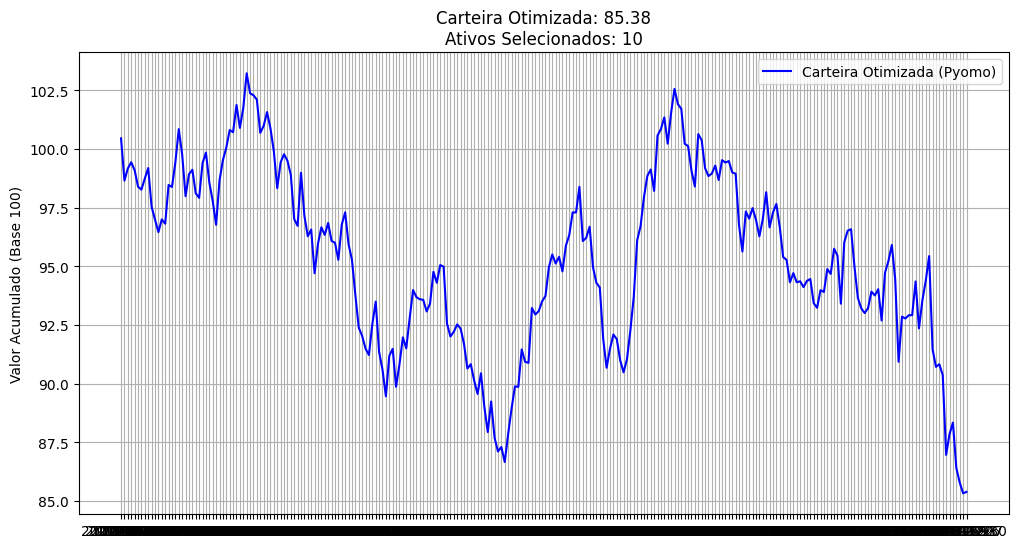

In [89]:
df_final_pietroski_1 = final_pietroski_1[final_pietroski_1['ativado']!=0]
print(df_final_pietroski_1.head(20))
ativos_selecionados = df_final_pietroski_1.index
retornos_carteira= dados_retorno_2024[ativos_selecionados]

carteira_otimizada = (retornos_carteira*df_final_pietroski_1['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100
# acum_equi = (carteira_equi).cumprod() * 100
# acum_ibov = (1 + retornos_ibov_primeira_metade['IBOV']).cumprod() * 100

print(acum_otimizado[-1])
# print(acum_equi[-1])
# print(acum_ibov[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
# plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada: {acum_otimizado[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()

### -------- 2º parte -  REBALANCEAMENTO

In [90]:
pesos_anteriores_pietroski_1 = {a: pyo.value(model_pietroski_1.x[a]) for a in model_pietroski_1.ativos}
pesos_anteriores_pietroski_1

{0: 0.15,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.15000000000000002,
 31: 0.02,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.039999999999999813,
 36: 0.02,
 37: 0.15000000000000002,
 38: 0.02,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.15000000000000002,
 43: 0.0,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.15000000000000002,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.15000000000000002,
 60: 0.0,
 61: 0.0}

In [99]:
score_2024_ativos_pietroski_2 = {}
i=0
for ticker in df_mf_2024['ticker'].unique():
    
    df_temp = df_mf_2024[df_mf_2024['ticker'] == ticker]
    # print(df_temp[['dt_refer', 'earnings_yield', 'ROIC']])
    score_anual = (0.25*df_temp['ROA']+0.25*df_temp['margem_liq'] + 0.25*df_temp['giro_ativo'] + 0.25*df_temp['alavancagem']).sum()
    score_2024_ativos_pietroski_2[i] = score_anual
    i=i+1
import math

# score_2024_ativos_pietroski_2
clean_dict = {k: v if math.isfinite(v) else 0 for k, v in score_2024_ativos_pietroski_2.items()}

score_2024_ativos_pietroski_2= clean_dict

## a ideia aqui é Compra e Venda ,
## mas nao binária, ou seja, nao é 0 nao compra e 1 compra,
# é porcentagem, o quanto comprar e o quanto vender , envolvende uma custo de transação

#criando modelo novo
model_B_pietroski_2 = pyo.ConcreteModel()

model_B_pietroski_2.ativos = pyo.RangeSet(0, len(dados_retorno_2025.columns)-1)
model_B_pietroski_2.dias = pyo.RangeSet(0, len(dados_retorno_2025)-1)
model_B_pietroski_2.ATIVOS_SEGUNDA_METADE = pyo.Param(model_B_pietroski_2.dias, model_B_pietroski_2.ativos,initialize=lambda model,dia, ativo: dados_retorno_2025.iloc[dia, ativo])
# model_B_pietroski_2.IBOV_SEGUNDA_METADE = pyo.Param(model_B_pietroski_2.dias, initialize = lambda model_B_pietroski_2,dia: retornos_ibov_segunda_metade['IBOV'].iloc[dia])

#como se fosse o problema da lista de saber o Quanto a empresa deve produzir e o Quanto a empresa deve comprar o produto de outra

#Definindo variáveis de compra e venda, que serão as usadas
model_B_pietroski_2.x = pyo.Var(model_B_pietroski_2.ativos, bounds=(0,1)) #novos pesos 
model_B_pietroski_2.y = pyo.Var(model_B_pietroski_2.ativos, within=pyo.Binary) #nova cardinalidade 
model_B_pietroski_2.compra =pyo.Var(model_B_pietroski_2.ativos, bounds=(0,1))
model_B_pietroski_2.venda =pyo.Var(model_B_pietroski_2.ativos, bounds=(0,1))
custo_taxa = 0.0003 # = 0.03%


model_B_pietroski_2.theta = pyo.Param(initialize=vb_theta)
model_B_pietroski_2.score = pyo.Param(model_B_pietroski_2.ativos, initialize=lambda model, ativo: score_2024_ativos_pietroski_2[ativo])
model_B_pietroski_2.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_B_pietroski_2.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_B_pietroski_2.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_B_pietroski_2.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

#OBJETIVO
def func_objetivo_2(model_B_pietroski_2):
    #como se trata de 2 momentos, o tracking e o custo de transação
    retorno_fundamentalista = sum((sum(model_B_pietroski_2.ATIVOS_SEGUNDA_METADE[dia, ativo] * model_B_pietroski_2.x[ativo] for ativo in model_B_pietroski_2.ativos)) for dia in model_B_pietroski_2.dias) + model_B_pietroski_2.theta * sum(
        model_B_pietroski_2.x[ativo]  * model_B_pietroski_2.score[ativo] for ativo in model_B_pietroski_2.ativos
    )
    
    score_total = model_B_pietroski_2.theta * sum(model_B_pietroski_2.x[a] * model_B_pietroski_2.score[a]  for a in model_B_pietroski_2.ativos)


    # Custo = taxa × (volume comprado + volume vendido)
    custo_transacao = sum(model_B_pietroski_2.compra[ativo] + model_B_pietroski_2.venda[ativo] for ativo in model_B_pietroski_2.ativos) * custo_taxa

    return retorno_fundamentalista + score_total - custo_transacao
    # return retorno_fundamentalista

model_B_pietroski_2.obj = pyo.Objective(rule=func_objetivo_2, sense=pyo.maximize)

#Restrições
#mais importante se a compra e venda será usada

def regra_equilibrio(model_B_pietroski_2, ativo):
    return model_B_pietroski_2.x[ativo] == pesos_anteriores_pietroski_1[ativo] + model_B_pietroski_2.compra[ativo] - model_B_pietroski_2.venda[ativo]

model_B_pietroski_2.regra_equilibrio = pyo.Constraint(model_B_pietroski_2.ativos, rule=regra_equilibrio)

#restrições de soma peso 1 ; de x só ser ativado se y = 1 ; de cardinalidade 15 para y

def model_B_soma_peso_1(model_B_pietroski_2):
    return sum(
        model_B_pietroski_2.x[ativo] for ativo in model_B_pietroski_2.ativos
    ) == 1
model_B_pietroski_2.model_B_soma_peso_1 = pyo.Constraint( rule=model_B_soma_peso_1)

def model_B_y_cardinalidade_max(model_B_pietroski_2):
    return sum(
        model_B_pietroski_2.y[ativo] for ativo in model_B_pietroski_2.ativos
    ) <= model_B_pietroski_2.cardinalidade_valor_max
model_B_pietroski_2.model_B_y_cardinalidade_total_max = pyo.Constraint(rule = model_B_y_cardinalidade_max)

def model_B_y_cardinalidade_min(model_B_pietroski_2):
    return sum(
        model_B_pietroski_2.y[ativo] for ativo in model_B_pietroski_2.ativos
    ) >= model_B_pietroski_2.cardinalidade_valor_min
model_B_pietroski_2.model_B_y_cardinalidade_total_min = pyo.Constraint(rule = model_B_y_cardinalidade_min)

def model_B_x_y(model_B_pietroski_2, ativo):
    return model_B_pietroski_2.x[ativo] <= model_B_pietroski_2.y[ativo]
model_B_pietroski_2.model_B_x_y = pyo.Constraint(model_B_pietroski_2.ativos, rule = model_B_x_y)

#peso maximo por acao
def rule_peso_maximo(model_B_pietroski_2, a):
    # return model_B_pietroski_2.x[a] <= 1/model_B_pietroski_2.cardinalidade_valor
    return model_B_pietroski_2.x[a] <= model_B_pietroski_2.peso_maximo

model_B_pietroski_2.const_peso_maximo = pyo.Constraint(model_B_pietroski_2.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model_B_pietroski_2, a):
    return model_B_pietroski_2.x[a] >= model_B_pietroski_2.peso_minimo * model_B_pietroski_2.y[a]  # se y=1, então x >= 0.05
model_B_pietroski_2.const_peso_minimo = pyo.Constraint(model_B_pietroski_2.ativos, rule=rule_peso_minimo)

def compra_ou_venda(model_B_pietroski_2, ativo):
    """Um ativo ou é comprado OU vendido, nunca os dois"""
    return model_B_pietroski_2.compra[ativo] + model_B_pietroski_2.venda[ativo] <= 1

model_B_pietroski_2.compra_ou_venda = pyo.Constraint(model_B_pietroski_2.ativos, rule=compra_ou_venda)

# def model_B_y_desativa_se_x_zero(model_B_pietroski_2, ativo):
#     """
#     Se x é pequeno (< peso_minimo), força y=0
#     Equivalente a: y <= x / peso_minimo
#     """
#     return model_B_pietroski_2.y[ativo] <= model_B_pietroski_2.x[ativo] / (model_B_pietroski_2.peso_minimo + 0.00001)

# model_B_pietroski_2.const_y_desativa = pyo.Constraint(model_B_pietroski_2.ativos, rule=model_B_pietroski_2_y_desativa_se_x_zero)



opt_B = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt_B.options['TimeLimit'] = 300
resultado = opt_B.solve(model_B_pietroski_2)



resultado = opt_B.solve(model_B_pietroski_2, tee=True)
print(f"\nStatus: {resultado.solver.status}")
print(f"Termination: {resultado.solver.termination_condition}")
print("-------FIM----------")


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmppupepjod.cplex.log' open.
CPLEX> New value for time limit in seconds: 300
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmph8j9g1wi.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmph8j9g1wi.pyomo.lp
Objective sense      : Maximize
Variables            :     248  [Box: 186,  Binary: 62]
Objective nonzeros   :     186
Linear constraints   :     313  [Less: 249,  Greater: 1,  Equal: 63]
  Nonzeros           :     806
  RHS nonzeros       :     137

Variables            : Min LB: 0.000000 

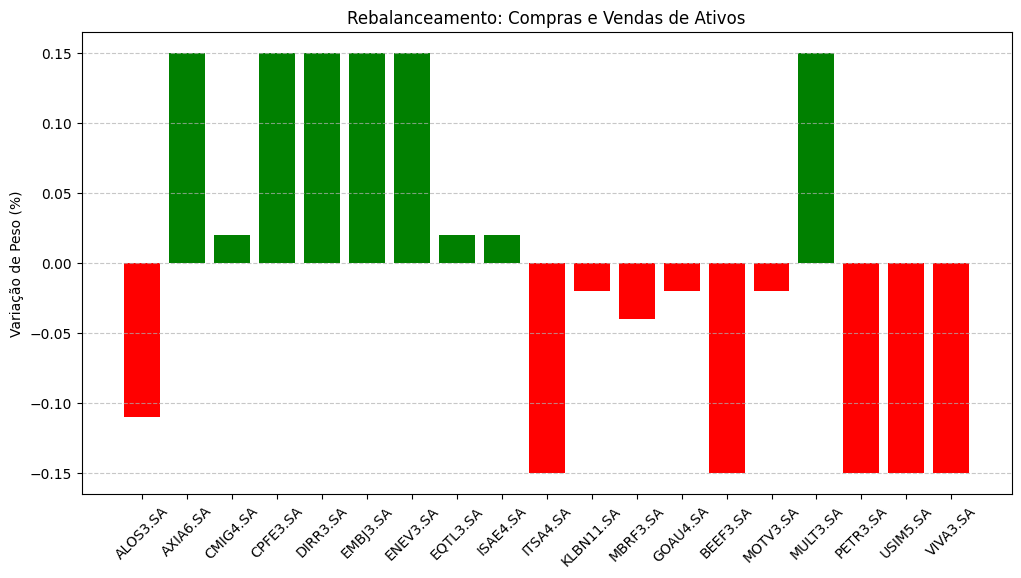

In [101]:
# Extrair os valores de compra e venda do model_B
mudancas_compra_pietroski_2 = []
mudancas_venda_pietroski_2 = []
mudancas_pietroski_2 = []
for a in range(len(dados_retorno_2024.columns)):
    c = pyo.value(model_B_pietroski_2.compra[a])
    v = pyo.value(model_B_pietroski_2.venda[a])
   
    mudancas_pietroski_2.append(c if c > 0.00001 else -v)

    
    # Se comprou, valor positivo; se vendeu, valor negativo
    mudancas_compra_pietroski_2.append(c)
    mudancas_venda_pietroski_2.append(v)

x_peso_final_pietroski_2 = []
y_ativado_final_pietroski_2 = []

for a in range(len(dados_retorno_2024.columns)):
    lista_x = pyo.value(model_B_pietroski_2.x[a])
    lista_y = pyo.value(model_B_pietroski_2.y[a])

    x_peso_final_pietroski_2.append(lista_x)
    y_ativado_final_pietroski_2.append(lista_y)
    
lista_peso_anterior_pietroski_1 = df_final_pietroski_1['peso_ativo'].tolist()
df_mudancas_pietroski_2 = pd.DataFrame({'Ativo': dados_retorno_2024.columns,'Mudança': mudancas_pietroski_2, 'Mudança_Compra': mudancas_compra_pietroski_2,"Mudança_venda":mudancas_venda_pietroski_2,'Ativado':y_ativado_final_pietroski_2, "Peso_otimizado":x_peso_final_pietroski_2})
# carteira_final['peso_anterior'] = lista_peso_anterior

df_mudancas2_final_pietroski_2 = df_mudancas_pietroski_2[df_mudancas_pietroski_2['Mudança'].abs() > 0.0001] # Filtrar apenas o que mudou
carteira_final_pietroski_2 = df_mudancas_pietroski_2[df_mudancas_pietroski_2['Ativado']>0.5]


plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in df_mudancas2_final_pietroski_2['Mudança']]
plt.bar(df_mudancas2_final_pietroski_2['Ativo'], df_mudancas2_final_pietroski_2['Mudança'], color=colors)
plt.xticks(rotation=45)
plt.title('Rebalanceamento: Compras e Vendas de Ativos')
plt.ylabel('Variação de Peso (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [102]:
carteira_final_pietroski_2

,Ativo,Mudança,Mudança_Compra,Mudança_venda,Ativado,Peso_otimizado
0,ALOS3.SA,-0.11,0.00,0.11,1.0,0.04
3,AXIA6.SA,0.15,0.15,0.00,1.0,0.15
9,CMIG4.SA,0.02,0.02,0.00,1.0,0.02
16,CPFE3.SA,0.15,0.15,0.00,1.0,0.15
18,DIRR3.SA,0.15,0.15,0.00,1.0,0.15
19,EMBJ3.SA,0.15,0.15,0.00,1.0,0.15
21,ENEV3.SA,0.15,0.15,0.00,1.0,0.15
23,EQTL3.SA,0.02,0.02,0.00,1.0,0.02
29,ISAE4.SA,0.02,0.02,0.00,1.0,0.02
40,MULT3.SA,0.15,0.15,0.00,1.0,0.15


In [104]:
print(len(df_final_pietroski_1))
print(df_final_pietroski_1)
print(df_mudancas2_final_pietroski_2)
print(carteira_final_pietroski_2)
print(len(carteira_final_pietroski_2))

10
           peso_ativo  ativado
ALOS3.SA         0.15      1.0
ITSA4.SA         0.15      1.0
KLBN11.SA        0.02      1.0
MBRF3.SA         0.04      1.0
GOAU4.SA         0.02      1.0
BEEF3.SA         0.15      1.0
MOTV3.SA         0.02      1.0
PETR3.SA         0.15      1.0
USIM5.SA         0.15      1.0
VIVA3.SA         0.15      1.0
        Ativo  Mudança  Mudança_Compra  Mudança_venda  Ativado  Peso_otimizado
0    ALOS3.SA    -0.11            0.00           0.11      1.0            0.04
3    AXIA6.SA     0.15            0.15           0.00      1.0            0.15
9    CMIG4.SA     0.02            0.02           0.00      1.0            0.02
16   CPFE3.SA     0.15            0.15           0.00      1.0            0.15
18   DIRR3.SA     0.15            0.15           0.00      1.0            0.15
19   EMBJ3.SA     0.15            0.15           0.00      1.0            0.15
21   ENEV3.SA     0.15            0.15           0.00      1.0            0.15
23   EQTL3.SA     0.02  

C:\Users\joaon\AppData\Local\Temp\ipykernel_19148\2939439263.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"


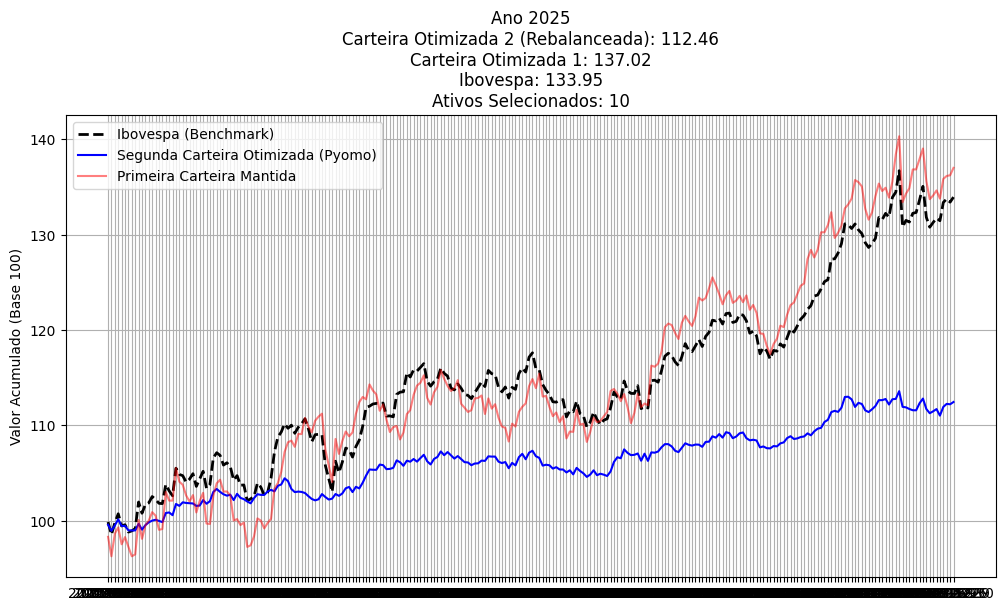

In [106]:
carteira_final2_pietroski_2 = carteira_final_pietroski_2['Peso_otimizado'].reset_index().drop(columns=['index']).set_index(carteira_final['Ativo'])
ativos_selecionados2_pietroski_2  = carteira_final_pietroski_2['Ativo'].tolist()
retornos_carteira2_pietroski_2  = dados_retorno_2025[ativos_selecionados2_pietroski_2]
carteira_otimizada2_pietroski_2  = 1 + (retornos_carteira2_pietroski_2 *carteira_final2_pietroski_2['Peso_otimizado']).sum(axis=1)

ativos_carteira_primeira = df_final_pietroski_1.index
retornos_carteira_primeira = dados_retorno_2025[ativos_carteira_primeira]
carteira_primeira = 1 +(retornos_carteira_primeira*df_final_pietroski_1['peso_ativo']).sum(axis=1)

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado2 = (carteira_otimizada2_pietroski_2).cumprod() *100
acum_otimizado1 = (carteira_primeira).cumprod() *100
# acum_equi = (carteira_equi).cumprod() * 100
acum_ibov2 = (1 + dados_retorno_ibov_2025).cumprod() * 100

# print(acum_otimizado2[-1])
# # print(acum_equi[-1])
# print(acum_ibov2[-1])

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov2, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado2, label='Segunda Carteira Otimizada (Pyomo)', color='blue')
plt.plot(acum_otimizado1, label='Primeira Carteira Mantida', color='red', alpha=0.5)

# texto_titulo = f'Comparação de Performance: Index Tracking ({tamanho_carteira_final} ativos)'
texto = f"Ano 2025\nCarteira Otimizada 2 (Rebalanceada): {acum_otimizado2[-1]:.2f}\nCarteira Otimizada 1: {acum_otimizado1[-1]:.2f}\nIbovespa: {acum_ibov2[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados2)}"

plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()